# First-order acoustic modelling — IVF free surface, dipping topography

Demonstrates the first-order velocity-pressure staggered-grid acoustic solver
with the **Improved Vacuum Formulation** (IVF) free-surface condition.

The acoustic system is the P-SV elastic equations with μ=0:

$$\frac{\partial v_x}{\partial t} = -b_x \frac{\partial p}{\partial x}, \qquad
  \frac{\partial v_z}{\partial t} = -b_z \frac{\partial p}{\partial z}, \qquad
  \frac{\partial p}{\partial t}   = -\kappa\left(\frac{\partial v_x}{\partial x} + \frac{\partial v_z}{\partial z}\right)$$

Grid staggering is the **dual** of the SH scheme: pressure $p$ sits at NODE,
velocities $v_x$, $v_z$ are staggered in $x$ and $z$ respectively.

**IVF rule (Pan et al. 2018):**
- The user pre-zeros `vp` and `rho` above the free surface (vacuum region).
- `κ = ρ v_p^2 = 0` in vacuum → `∂p/∂t = 0` → pressure stays 0 automatically.
- `b_x`, `b_z` use Pan eqs. 9–10: at a solid/vacuum interface the averaged
  buoyancy doubles (`2/ρ_solid`), enforcing the zero-pressure free-surface BC.
- No modulus averaging is required (no shear term).

**Units** (same convention as all Devito seismic examples):

| Quantity | Unit |
|----------|------|
| distance / spacing | m |
| velocity | km/s |
| density  | g/cm³ |
| time     | ms |
| κ = ρ·vp² | g·km²/(cm³·s²) |

**PML note:** the absorbing layer must be at least 1–2 dominant wavelengths
thick. At vp_min = 0.5 km/s and f0 = 40 Hz the dominant wavelength is
λ = 12.5 m. With dx = 0.5 m, `nbl = 100` (50 m PML) provides adequate
absorption and numerical stability.

**Scenario** (adapted from Pan et al. 2018, Figs. 7–8 for P-waves):
dipping planar free surface (10 °) with a linear-gradient P-wave velocity model.

| Parameter | Value |
|-----------|-------|
| Dip angle | 10 ° |
| vp at surface | 0.50 km/s |
| vp gradient | 0.06 km/s per metre depth |
| Density (solid) | 2.0 g/cm³ |
| Grid spacing | 0.5 m |
| Physical domain | 50 m × 30 m |
| nbl (PML layers) | 100 |
| Source | Ricker 0.040 kHz (40 Hz), at x = 5 m on the surface |
| Receivers | x = 10–45 m along the surface (36 traces) |
| Simulation time | 80 ms |

In [1]:
import numpy as np
from matplotlib import pyplot as plt
from matplotlib.colors import TwoSlopeNorm

from devito import TimeFunction, NODE

from examples.seismic import AcquisitionGeometry
from examples.seismic.model import ModelAcousticIVF
from examples.seismic.acoustic_ivf.operators import ForwardOperator

## 1. Model

In [2]:
# ── Grid parameters ────────────────────────────────────────────────────────────
dx          = 0.1          # m
nx, nz      = 500, 500      # grid points (physical domain 50 m × 30 m)
# nbl must be at least 1–2 dominant wavelengths thick.
# At vp=0.5 km/s and f0=40 Hz: λ ≈ 12.5 m → nbl=100 gives a 50 m PML.
nbl         = 200
space_order = 4
dip_deg     = 5.0

# ── Dipping free surface ───────────────────────────────────────────────────────
# z_surf[ix] = first solid z-index at column ix.
# Surface dips down to the right at dip_deg degrees.
n_vac  = 8    # vacuum rows at the left (shallow) edge
z_surf = np.round(
    n_vac + np.arange(nx) * np.tan(np.radians(dip_deg))
).astype(int)
z_surf = np.clip(z_surf, 1, nz - 2)

# ── Physical model — vp [km/s], rho [g/cm³]; zeros above surface (vacuum) ─────
vp_arr  = np.zeros((nx, nz), dtype=np.float32)
rho_arr = np.zeros((nx, nz), dtype=np.float32)

v0   = 0.50   # km/s at the free surface
grad = 0.06   # km/s per metre of depth below surface
rho0 = 1.0    # g/cm³ (constant in solid)

for ix in range(nx):
    iz_s           = z_surf[ix]
    depths         = np.arange(nz - iz_s) * dx   # depth below local surface [m]
    vp_arr[ix, iz_s:]  = np.float32(v0 + grad * depths)
    rho_arr[ix, iz_s:] = rho0

vp_arr  = np.zeros((nx, nz), dtype=np.float32)
rho_arr = np.zeros((nx, nz), dtype=np.float32)

v0   = 0.50   # km/s at the free surface
grad = 0.06   # km/s per metre of depth (normal to surface)
rho0 = 1.0    # g/cm³ (constant in solid)

# Compute unit normal vectors to the dipping surface
# Surface slope: tan_theta = tan(dip_deg)
tan_theta = np.tan(np.radians(dip_deg))
cos_theta = 1.0 / np.sqrt(1.0 + tan_theta**2)
sin_theta = tan_theta * cos_theta

# Normal vector components (pointing downward into the solid)
# For a surface defined as z_surf[ix] = constant + ix * tan_theta
# The upward normal is (-sin_theta, cos_theta), so downward normal is (sin_theta, -cos_theta)
# But careful: our grid indices are (x, z) with z increasing downward
# So the normal vector components in (x, z) coordinates:
nx_norm = sin_theta   # x-component (horizontal)
nz_norm = cos_theta   # z-component (vertical, positive downward)

print(f"Surface dip: {dip_deg}°")
print(f"Normal vector (x, z): ({nx_norm:.4f}, {nz_norm:.4f})")

for ix in range(nx):
    iz_s = z_surf[ix]
    
    # For each point below the surface, compute perpendicular distance
    # to the dipping surface (not vertical depth)
    for iz in range(iz_s, nz):
        # Vector from surface point to current grid point
        dx_surf = (ix - ix) * dx  # = 0 in x (since same column)
        dz_surf = (iz - iz_s) * dx
        
        # But the surface is dipping, so we need the actual perpendicular distance
        # The surface at column ix has a local normal. The signed perpendicular
        # distance from a point (ix, iz) to the surface plane passing through
        # (ix, iz_s) with normal (nx_norm, nz_norm):
        # 
        # More accurately: For a dipping surface, the distance should be measured
        # along the normal direction. The surface is defined at each column,
        # but the "depth below surface" in the normal direction requires
        # projecting the vector from surface point to the grid point onto the normal.
        
        # Method 1: Simple projection onto normal
        # Vector from surface reference point (ix, iz_s) to current point
        # Since we're in the same column, dx = 0, dz = (iz - iz_s)*dx
        vec_x = 0.0
        vec_z = (iz - iz_s) * dx
        
        # Perpendicular distance = projection onto normal
        perp_dist = abs(vec_x * nx_norm + vec_z * nz_norm)
        
        vp_arr[ix, iz] = np.float32(v0 + grad * perp_dist)
        rho_arr[ix, iz] = rho0


# ── Build ModelAcousticIVF ─────────────────────────────────────────────────────
# Origin: z=0 at the shallowest free-surface point (left edge).
origin = (0., -n_vac * dx)

model = ModelAcousticIVF(
    origin=origin,
    spacing=(dx, dx),
    shape=(nx, nz),
    space_order=space_order,
    vp=vp_arr,
    rho=rho_arr,
    nbl=nbl,
    topo=z_surf,
)

print(f'critical_dt  = {model.critical_dt:.4f} ms')
print(f'padded grid  = {model.grid.shape}')
print(f'vp range     = {vp_arr[vp_arr > 0].min():.3f} – {vp_arr.max():.3f} km/s')
print(f'kappa range  = {model.kappa.data[model.kappa.data > 0].min():.3f} – '
      f'{model.kappa.data.max():.3f}  [g·km²/(cm³·s²)]')

# Sanity check: b_z at vacuum/solid boundary = 2/rho0 (doubled buoyancy)
ix_c   = 0
iz_bnd = z_surf[ix_c]
b_z_at_bnd = model.b_z.data[nbl + ix_c, nbl + iz_bnd - 1]
print(f'\nb_z at vacuum/solid boundary: {b_z_at_bnd:.6f}  '
      f'(expected 2/rho0 = {2/rho0:.6f})')

Surface dip: 5.0°
Normal vector (x, z): (0.0872, 0.9962)


Operator `initdamp` ran in 0.01 s


critical_dt  = 0.0168 ms
padded grid  = (np.int64(900), np.int64(900))
vp range     = 0.500 – 3.435 km/s
kappa range  = 0.250 – 11.798  [g·km²/(cm³·s²)]

b_z at vacuum/solid boundary: 2.000000  (expected 2/rho0 = 2.000000)


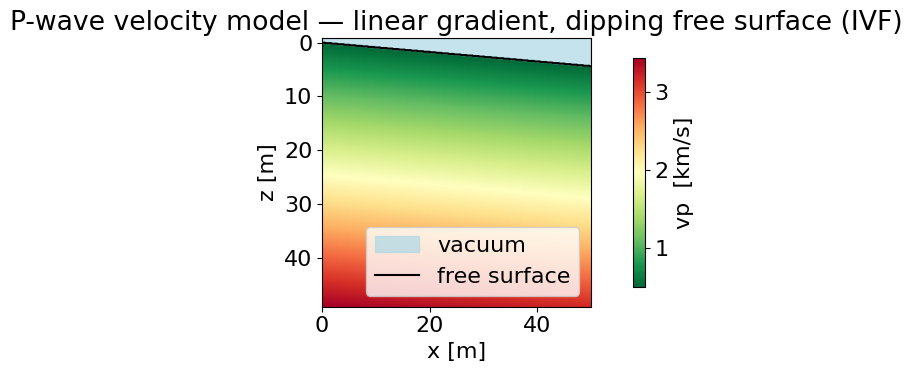

In [3]:
# Plot vp model with surface overlay
x_phys   = np.arange(nx) * dx                    # m
z_phys   = origin[1] + np.arange(nz) * dx        # m (negative = below z=0)
surf_z_m = origin[1] + z_surf * dx               # m, free-surface elevation

fig, ax = plt.subplots(figsize=(9, 4))
vp_plot = np.ma.masked_where(vp_arr == 0, vp_arr)
im = ax.imshow(vp_plot.T,
                   cmap='RdYlGn_r', interpolation='bilinear',
                   vmin=v0, vmax=vp_arr.max(), extent=[x_phys[0], x_phys[-1], z_phys[-1], z_phys[0]])
ax.fill_between(x_phys, z_phys[0], surf_z_m, color='lightblue', alpha=0.7,
                label='vacuum')
ax.plot(x_phys, surf_z_m, 'k-', lw=1.5, label='free surface')
plt.colorbar(im, ax=ax, label='vp  [km/s]', shrink=0.85)
ax.set_xlabel('x [m]')
ax.set_ylabel('z [m]')
ax.set_title('P-wave velocity model — linear gradient, dipping free surface (IVF)')
ax.legend(loc='lower right')
# ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 2. Geometry

In [4]:
t0, tn = 0., 250.    # ms
f0     = 0.050      # kHz  =  40 Hz

# Source on the surface at x = 5 m
pos = 5.0
src_ix     = int(pos / dx)
src_coords = np.array([[pos, origin[1] + (z_surf[src_ix]+1) * dx]],
                      dtype=np.float32)

# 36 receivers along the dipping surface from x = 10 to 45 m
rec_x   = np.linspace(0., 45., 46, dtype=np.float32)
rec_ix  = (rec_x / dx).astype(int)
rec_coords = np.column_stack(
    [rec_x, origin[1] + z_surf[rec_ix] * dx]
).astype(np.float32)

geometry = AcquisitionGeometry(
    model, rec_coords, src_coords,
    t0=t0, tn=tn, src_type='Ricker', f0=f0,
)

dt = model.critical_dt
print(f'dt = {dt} ms,  nt = {geometry.nt}')

dt = 0.016759999096393585 ms,  nt = 14918


## 3. Operator and wavefield buffers

In [5]:
op = ForwardOperator(model, geometry, space_order=space_order)

x, z = model.grid.dimensions

p  = TimeFunction(name='p',  grid=model.grid, space_order=space_order,
                  time_order=1, staggered=NODE)
vx = TimeFunction(name='vx', grid=model.grid, space_order=space_order,
                  time_order=1, staggered=(x,))
vz = TimeFunction(name='vz', grid=model.grid, space_order=space_order,
                  time_order=1, staggered=(z,))
rec = geometry.new_rec(name='rec')

## 4. Run

In [6]:
op.apply(
    p=p, vx=vx, vz=vz,
    src=geometry.src, rec=rec,
    dt=dt,
    **model.physical_params(),
)
print(f'|rec|_max = {np.abs(rec.data).max():.4e}')

Operator `ForwardAcousticIVF` ran in 25.33 s


|rec|_max = 4.3268e-03


## 5. Results

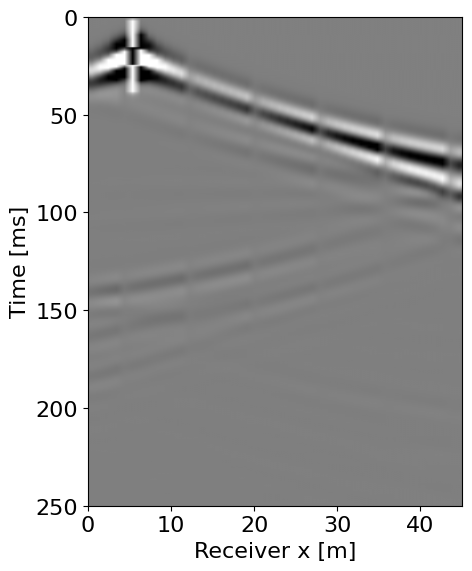

In [7]:
# Seismogram: pressure recorded along the dipping surface
seismogram = np.array(rec.data)          # shape (nt, nrec)
clip = np.percentile(np.abs(seismogram), 99) or 1.0

fig, ax = plt.subplots(figsize=(5, 6))
ax.imshow(
    seismogram,
    aspect='auto',
    cmap='gray',
    vmin=-clip, vmax=clip,
    extent=[rec_x[0], rec_x[-1], tn, t0],
    interpolation='bilinear',
)
ax.set_xlabel('Receiver x [m]')
ax.set_ylabel('Time [ms]')
# ax.set_title('Pressure seismogram — dipping free surface (IVF, 40 Hz Ricker)')
plt.tight_layout()
plt.show()

In [8]:
# Wavefield snapshot: run again saving full pressure time history
p_full = TimeFunction(name='p_full', grid=model.grid, save=geometry.nt,
                      space_order=space_order, time_order=1, staggered=NODE)
vx2 = TimeFunction(name='vx2', grid=model.grid, space_order=space_order,
                   time_order=1, staggered=(x,))
vz2 = TimeFunction(name='vz2', grid=model.grid, space_order=space_order,
                   time_order=1, staggered=(z,))
rec2 = geometry.new_rec(name='rec2')

op.apply(
    p=p_full, vx=vx2, vz=vz2,
    src=geometry.src, rec=rec2,
    dt=dt,
    **model.physical_params(),
)

# Extract physical domain (strip PML padding)
t_snap = int(geometry.nt * 0.55)
snap   = p_full.data[t_snap, nbl:-nbl, nbl:-nbl]   # shape (nx, nz)
t_ms   = t0 + t_snap * dt
clip_s = np.percentile(np.abs(snap), 99) or 1.0

fig, ax = plt.subplots(figsize=(9, 4))
norm = TwoSlopeNorm(vmin=-clip_s, vcenter=0, vmax=clip_s)
ax.pcolormesh(x_phys, z_phys, snap.T,
              cmap='RdBu_r', norm=norm, shading='auto')
ax.fill_between(x_phys, z_phys[0], surf_z_m, color='white', alpha=0.9)
ax.plot(x_phys, surf_z_m, 'k-', lw=1.5)
ax.plot(*src_coords[0], 'r*', ms=10, label='source')
ax.plot(rec_x, (origin[1] + z_surf[rec_ix] * dx), 'kv', ms=4, label='receivers')
ax.set_xlabel('x [m]')
ax.set_ylabel('z [m]')
ax.set_title(f'Pressure snapshot at t = {t_ms:.1f} ms')
ax.legend(loc='lower right')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

RuntimeError: Unable to allocate 12299353952 elements in memory